# Twin SVM sur le Dataset Spambase

**Algorithme :** Twin Support Vector Machine  — implémentation from scratch  
**Dataset :** Spambase (UCI) — classification d'e-mails spam vs non-spam  
**Split :** 70 % train / 15 % validation / 15 % test  
**Objectif :** Classer les e-mails en *spam* (1) vs *non-spam* (0) en résolvant deux petits QP au lieu d'un grand

In [31]:
%pip install cvxopt

Note: you may need to restart the kernel to use updated packages.


In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)
import cvxopt
from cvxopt import matrix, solvers
from numpy.linalg import inv

import warnings
warnings.filterwarnings('ignore')
cvxopt.solvers.options['show_progress'] = False

np.random.seed(42)

SPAMBASE — APERÇU GÉNÉRAL
Samples      : 4601
Features     : 57
Spam (1)     : 1813 (39.4%)
Non-spam (0) : 2788 (60.6%)
Valeurs NaN  : 0

Features constantes : Aucune

STATISTIQUES DESCRIPTIVES (8 premières features)
       word_freq_make  word_freq_address  word_freq_all  word_freq_3d  word_freq_our  word_freq_over  word_freq_remove  word_freq_internet
count        4601.000           4601.000       4601.000      4601.000       4601.000        4601.000          4601.000            4601.000
mean            0.105              0.213          0.281         0.065          0.312           0.096             0.114               0.105
std             0.305              1.291          0.504         1.395          0.673           0.274             0.391               0.401
min             0.000              0.000          0.000         0.000          0.000           0.000             0.000               0.000
25%             0.000              0.000          0.000         0.000          0.000    

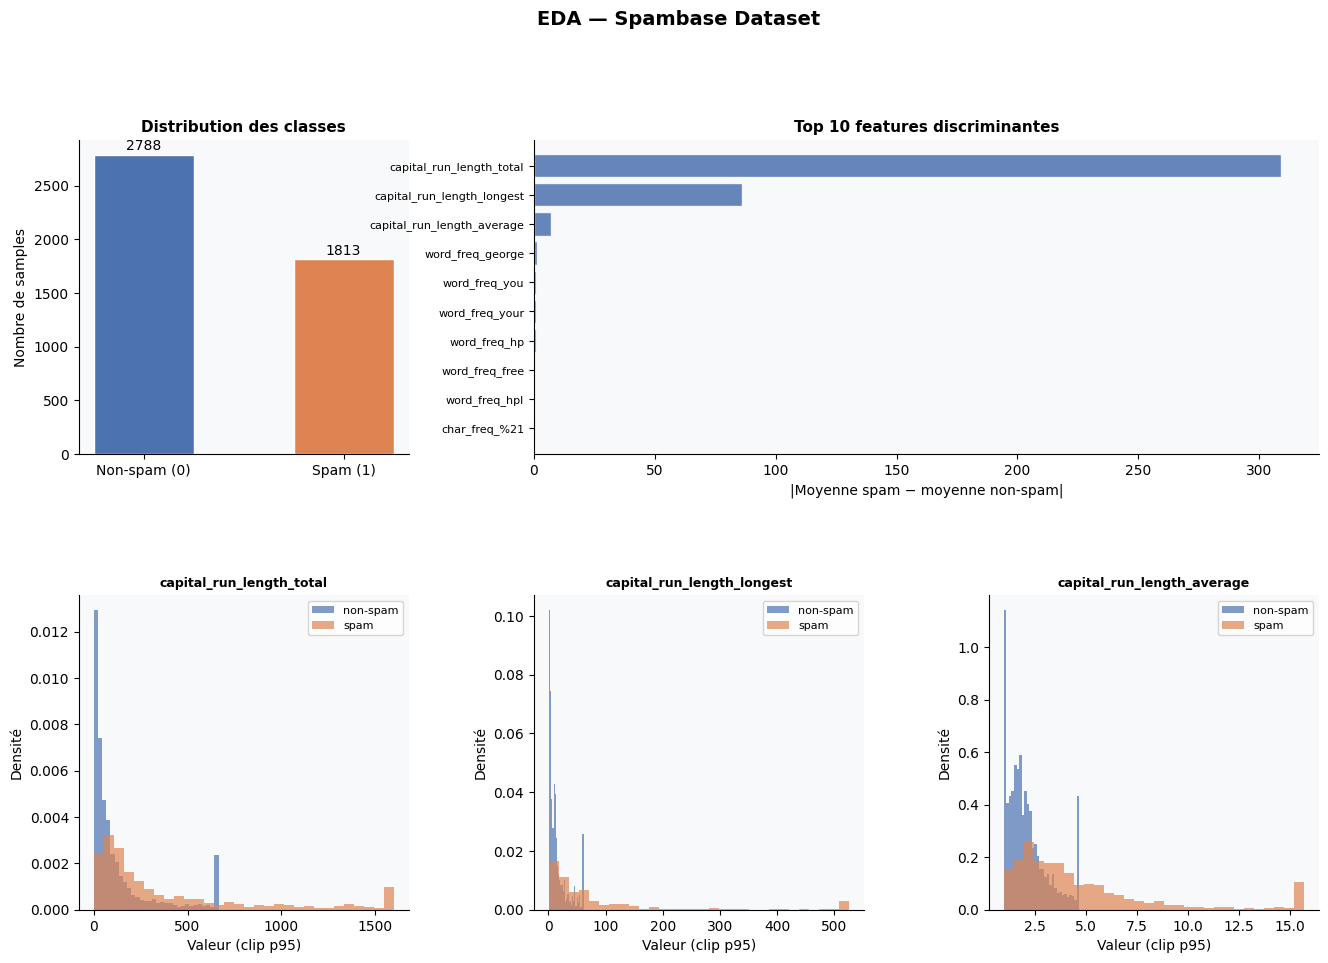

In [33]:
# Chargement
data = fetch_openml(name='spambase', version=1, as_frame=True, parser='auto')
X_raw = data.data.astype(float).copy()
y_raw = data.target.astype(int).copy()

print("SPAMBASE — APERÇU GÉNÉRAL")
print(f"Samples      : {X_raw.shape[0]}")
print(f"Features     : {X_raw.shape[1]}")
print(f"Spam (1)     : {(y_raw == 1).sum()} ({(y_raw == 1).mean()*100:.1f}%)")
print(f"Non-spam (0) : {(y_raw == 0).sum()} ({(y_raw == 0).mean()*100:.1f}%)")
print(f"Valeurs NaN  : {X_raw.isnull().sum().sum()}")

# Features constantes
std_per_feature = X_raw.std()
constant_cols = std_per_feature[std_per_feature == 0].index.tolist()
print(f"\nFeatures constantes : {constant_cols if constant_cols else 'Aucune'}")

# Statistiques descriptives
print("\nSTATISTIQUES DESCRIPTIVES (8 premières features)")
print(X_raw.iloc[:, :8].describe().round(3).to_string())

# Features les plus discriminantes (diff de moyenne spam vs non-spam)
X_eda = X_raw.copy()
X_eda['label'] = y_raw.values
mean_diff = (
    X_eda[X_eda['label'] == 1].drop(columns='label').mean() -
    X_eda[X_eda['label'] == 0].drop(columns='label').mean()
).abs().sort_values(ascending=False)

print("\nTOP 10 FEATURES (différence de moyenne |spam - non-spam|)")
print(mean_diff.head(10).round(4).to_string())

# Corrélations entre top features
top10_feats = mean_diff.head(10).index.tolist()

# Visualisations EDA
fig = plt.figure(figsize=(16, 10))
fig.patch.set_facecolor('white')
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.38)

colors = ['#4C72B0', '#DD8452']

# Distribution des classes
ax0 = fig.add_subplot(gs[0, 0])
class_counts = y_raw.value_counts().sort_index()
bars = ax0.bar(['Non-spam (0)', 'Spam (1)'], class_counts.values,
               color=colors, width=0.5, edgecolor='white')
for bar, val in zip(bars, class_counts.values):
    ax0.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 15,
             str(val), ha='center', va='bottom', fontsize=10)
ax0.set_title('Distribution des classes', fontsize=11, fontweight='bold')
ax0.set_ylabel('Nombre de samples')
ax0.set_facecolor('#f8f9fa')
ax0.spines[['top','right']].set_visible(False)

# Top 10 features discriminantes
ax1 = fig.add_subplot(gs[0, 1:])
ax1.barh(range(10), mean_diff.head(10).values[::-1],
         color='#4C72B0', alpha=0.85, edgecolor='white')
ax1.set_yticks(range(10))
ax1.set_yticklabels(mean_diff.head(10).index[::-1], fontsize=8)
ax1.set_xlabel('|Moyenne spam − moyenne non-spam|')
ax1.set_title('Top 10 features discriminantes', fontsize=11, fontweight='bold')
ax1.set_facecolor('#f8f9fa')
ax1.spines[['top','right']].set_visible(False)

# Distribution des 3 features les plus discriminantes
X_spam = X_eda[X_eda['label'] == 1].drop(columns='label')
X_nospam = X_eda[X_eda['label'] == 0].drop(columns='label')
top3 = mean_diff.head(3).index.tolist()

for i, feat in enumerate(top3):
    ax = fig.add_subplot(gs[1, i])
    vals_spam = X_spam[feat].clip(upper=X_spam[feat].quantile(0.95))
    vals_nospam = X_nospam[feat].clip(upper=X_nospam[feat].quantile(0.95))
    ax.hist(vals_nospam, bins=30, alpha=0.7, color=colors[0],
            label='non-spam', density=True)
    ax.hist(vals_spam, bins=30, alpha=0.7, color=colors[1],
            label='spam', density=True)
    ax.set_title(f'{feat}', fontsize=9, fontweight='bold')
    ax.set_xlabel('Valeur (clip p95)')
    ax.set_ylabel('Densité')
    ax.legend(fontsize=8)
    ax.set_facecolor('#f8f9fa')
    ax.spines[['top','right']].set_visible(False)

fig.suptitle('EDA — Spambase Dataset', fontsize=14, fontweight='bold', y=1.01)
plt.show();

In [34]:
# Preprocessing 
X_clean   = X_raw.values
y_encoded = np.where(y_raw.values == 1, 1.0, -1.0)

X_train, X_temp, y_train, y_temp = train_test_split(
    X_clean, y_encoded, test_size=0.30, random_state=42, stratify=y_encoded
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

print(f"Train : {X_train.shape[0]} samples")
print(f"Val   : {X_val.shape[0]} samples")
print(f"Test  : {X_test.shape[0]} samples")


# Implémentation Twin SVM from scratch 
class TwinSVM:
    """
    Twin Support Vector Machine — noyau linéaire.

    Idée : on cherche deux hyperplans H1 et H2.
      - H1 colle à la classe +1, s'éloigne de la classe -1
      - H2 colle à la classe -1, s'éloigne de la classe +1

    Chaque hyperplan est solution d'un QP de taille ~n/2
    (vs un seul QP de taille n pour le SVM classique).
    Le classement se fait selon l'hyperplan le plus proche.
    """

    def __init__(self, c1=1.0, c2=1.0, reg=1e-4):
        self.c1  = c1    # pénalisation erreurs sur H1 (classe -1 trop proche)
        self.c2  = c2    # pénalisation erreurs sur H2 (classe +1 trop proche)
        self.reg = reg   # régularisation numérique (stabilité de l'inverse)

    def _solve_qp(self, H_mat, q_vec, upper_bound):
        """Résout : min 1/2 α^T H α - e^T α  s.t. 0 <= α <= c"""
        n   = H_mat.shape[0]
        P   = matrix(H_mat, tc='d')
        q   = matrix(-np.ones(n), tc='d')
        G   = matrix(np.vstack([-np.eye(n), np.eye(n)]), tc='d')
        h   = matrix(np.hstack([np.zeros(n), upper_bound * np.ones(n)]), tc='d')
        sol = solvers.qp(P, q, G, h)
        return np.array(sol['x']).flatten()

    def fit(self, X, y):
        A = X[y ==  1]   # classe +1
        B = X[y == -1]   # classe -1
        m, n = A.shape[0], B.shape[0]

        # Matrices augmentées (features + biais)
        S = np.hstack([A, np.ones((m, 1))])  
        R = np.hstack([B, np.ones((n, 1))])  # shape (n, d+1)

        # Inverses régularisées
        StS_inv = inv(S.T @ S + self.reg * np.eye(S.shape[1]))
        RtR_inv = inv(R.T @ R + self.reg * np.eye(R.shape[1]))

        # QPP1 : hyperplan H1 (proche de +1, loin de -1)
        H1 = R @ StS_inv @ R.T
        H1 += 1e-8 * np.eye(n)          # stabilité numérique
        alpha = self._solve_qp(H1, None, self.c1)
        u1 = -StS_inv @ R.T @ alpha      # [w1; b1]
        self.w1_, self.b1_ = u1[:-1], u1[-1]

        # QPP2 : hyperplan H2 (proche de -1, loin de +1) 
        H2 = S @ RtR_inv @ S.T
        H2 += 1e-8 * np.eye(m)
        gamma = self._solve_qp(H2, None, self.c2)
        u2 = RtR_inv @ S.T @ gamma       # [w2; b2]
        self.w2_, self.b2_ = u2[:-1], u2[-1]

        return self

    def decision_function(self, X):
        """Score = distance à H2 − distance à H1 (positif → classe +1)."""
        d1 = np.abs(X @ self.w1_ + self.b1_)
        d2 = np.abs(X @ self.w2_ + self.b2_)
        return d2 - d1

    def predict(self, X):
        """Assignation selon l'hyperplan le plus proche."""
        d1 = np.abs(X @ self.w1_ + self.b1_)
        d2 = np.abs(X @ self.w2_ + self.b2_)
        return np.where(d1 <= d2, 1.0, -1.0)


# Entraînement — configuration unique
model = TwinSVM(c1=1.0, c2=1.5)
model.fit(X_train, y_train)


# Évaluation 
def evaluate(model, X, y, split_name):
    y_pred  = model.predict(X)
    y_score = model.decision_function(X)
    auc     = roc_auc_score(y, y_score)
    print(split_name)
    print(classification_report(y, y_pred,
                                 target_names=['non-spam (-1)', 'spam (+1)']))
    print(f"ROC-AUC : {auc:.4f}")
    return y_pred, y_score

y_pred_val,  y_score_val  = evaluate(model, X_val,  y_val,  "VALIDATION SET")


Train : 3220 samples
Val   : 690 samples
Test  : 691 samples
VALIDATION SET
               precision    recall  f1-score   support

non-spam (-1)       0.94      0.93      0.94       418
    spam (+1)       0.89      0.91      0.90       272

     accuracy                           0.92       690
    macro avg       0.92      0.92      0.92       690
 weighted avg       0.92      0.92      0.92       690

ROC-AUC : 0.9681


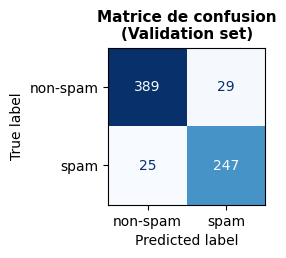

In [35]:
fig = plt.figure(figsize=(15, 5))
fig.patch.set_facecolor('white')
ax1 = fig.add_subplot(gs[0, 0])
cm = confusion_matrix(y_val, y_pred_val)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['non-spam', 'spam'])
disp.plot(ax=ax1, colorbar=False, cmap='Blues')
ax1.set_title('Matrice de confusion\n(Validation set)', fontsize=11, fontweight='bold')
ax1.set_facecolor('white')
plt.show();

In [36]:
y_pred_test, y_score_test = evaluate(model, X_test, y_test, "TEST SET")

TEST SET
               precision    recall  f1-score   support

non-spam (-1)       0.92      0.95      0.93       419
    spam (+1)       0.92      0.87      0.89       272

     accuracy                           0.92       691
    macro avg       0.92      0.91      0.91       691
 weighted avg       0.92      0.92      0.92       691

ROC-AUC : 0.9662


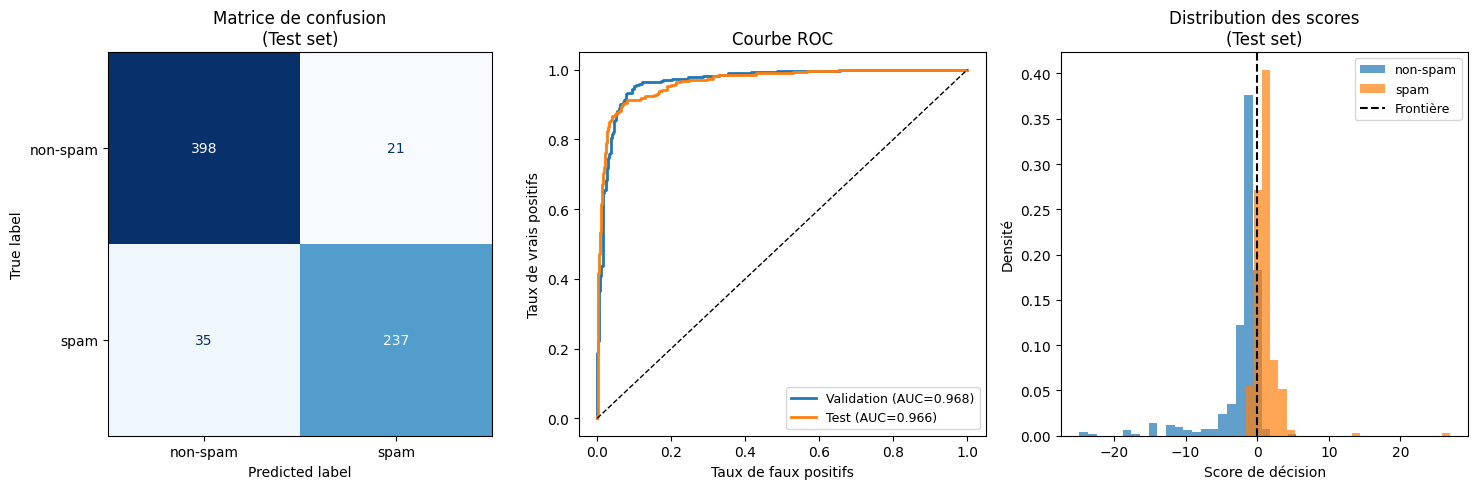

In [37]:
# Panel de visualisation simplifié
fig = plt.figure(figsize=(15, 5))
gs = gridspec.GridSpec(1, 3, figure=fig)

# Matrice de confusion (test)
ax1 = fig.add_subplot(gs[0, 0])
cm = confusion_matrix(y_test, y_pred_test)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['non-spam', 'spam'])
disp.plot(ax=ax1, colorbar=False, cmap='Blues')
ax1.set_title('Matrice de confusion\n(Test set)')

# Courbe ROC — val + test
ax2 = fig.add_subplot(gs[0, 1])
for y_true, y_score, label in [
    (y_val,  y_score_val,  'Validation'),
    (y_test, y_score_test, 'Test')
]:
    fpr, tpr, _ = roc_curve(y_true, y_score)
    auc = roc_auc_score(y_true, y_score)
    ax2.plot(fpr, tpr, lw=2, label=f'{label} (AUC={auc:.3f})')
ax2.plot([0, 1], [0, 1], 'k--', lw=1)
ax2.set_xlabel('Taux de faux positifs')
ax2.set_ylabel('Taux de vrais positifs')
ax2.set_title('Courbe ROC')
ax2.legend(fontsize=9)

# Distribution des scores de décision
ax3 = fig.add_subplot(gs[0, 2])
for val, label in [
    (y_score_test[y_test == -1], 'non-spam'),
    (y_score_test[y_test ==  1], 'spam')
]:
    ax3.hist(val, bins=25, alpha=0.7, label=label, density=True)
ax3.axvline(0, color='black', linestyle='--', lw=1.5, label='Frontière')
ax3.set_xlabel('Score de décision')
ax3.set_ylabel('Densité')
ax3.set_title('Distribution des scores\n(Test set)')
ax3.legend(fontsize=9)

plt.tight_layout()
plt.show();